# Portfolio Construction — ViT Candlestick Signals
**Group 5 | AI in Finance | COMM 486I**

### Required files
| File | Description |
|---|---|
| `crsp_full.csv` | Full CRSP download (1.37GB, 37M rows) |
| `vit_chunk1.csv` | ViT signals chunk 1-40 (permno, date, signal) |
| `vit_chunk2.csv` | ViT signals chunk 40-89 (path, signal, label) |
| `ff3.csv` | Fama-French 3 factors + momentum (WRDS) |

---
## SETUP — Mount Drive & Install

In [1]:
import os
os.rename('cibulhhkus1mp8go.csv', 'crsp_full.csv')
os.rename('notebooks_vit_signals_chunk_40.csv', 'vit_chunk1.csv')
os.rename('vit_signals_chunk_40_89 (1).csv', 'vit_chunk2.csv')
os.rename('notebooks_ff3.csv', 'ff3.csv')
print('Files ready:')
print([f for f in os.listdir() if f.endswith('.csv')])

Files ready:
['crsp_full.csv', 'vit_chunk1.csv', 'vit_chunk2.csv', 'ff3.csv']


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from glob import glob
from tqdm import tqdm

os.makedirs('pred/vit', exist_ok=True)
os.makedirs('sorted_portfolio', exist_ok=True)
print('Ready')

Mounted at /content/drive
Ready


---
## STEP 1 — Load & Merge ViT Signal Chunks
Chunk 1 format: `permno, date, signal`  
Chunk 2 format: `path, signal, label` — permno and date extracted from path

In [3]:
# ── Chunk 1 (1-40) ────────────────────────────────────────────
c1 = pd.read_csv('vit_chunk1.csv')
c1.columns = c1.columns.str.lower()
c1['date'] = pd.to_datetime(c1['date'])
c1 = c1[['permno','date','signal']].rename(columns={'signal':'signal_c1'})
print(f'Chunk1: {c1.shape[0]:,} rows | {c1["permno"].nunique():,} stocks | {c1["date"].min().date()} to {c1["date"].max().date()}')

# ── Chunk 2 (40-89) ───────────────────────────────────────────
c2 = pd.read_csv('vit_chunk2.csv')
c2.columns = c2.columns.str.lower()
# Extract permno and date from path column
c2['permno'] = c2['path'].str.extract(r'/(\d+)_\d+\.png').astype(int)
c2['date']   = pd.to_datetime(c2['path'].str.extract(r'/\d+_(\d{8})\.png')[0], format='%Y%m%d')
c2 = c2[['permno','date','signal']].rename(columns={'signal':'signal_c2'})
print(f'Chunk2: {c2.shape[0]:,} rows | {c2["permno"].nunique():,} stocks | {c2["date"].min().date()} to {c2["date"].max().date()}')

# ── Merge and average ─────────────────────────────────────────
signals = c1.merge(c2, on=['permno','date'], how='outer')
signals['signal'] = signals[['signal_c1','signal_c2']].mean(axis=1)
signals = signals[['permno','date','signal']].dropna()
print(f'\nCombined: {len(signals):,} rows | {signals["permno"].nunique():,} stocks')
del c1, c2; gc.collect()

Chunk1: 2,889,904 rows | 1,604 stocks | 2001-01-02 to 2020-07-02
Chunk2: 2,889,904 rows | 1,604 stocks | 2001-01-02 to 2020-07-02

Combined: 2,889,904 rows | 1,604 stocks


19

---
## STEP 2 — Build Market Data pkl Files from Full CRSP

In [4]:
print('Loading CRSP (this takes 3-5 min for 1.37GB)...')
crsp = pd.read_csv('crsp_full.csv')
crsp.columns = crsp.columns.str.lower().str.strip()
print('Columns:', crsp.columns.tolist())
crsp['date'] = pd.to_datetime(crsp['date'])
crsp['prc']  = crsp['prc'].abs()
crsp['cap']  = crsp['shrout'] * crsp['prc']

print(f'Date range   : {crsp["date"].min().date()} to {crsp["date"].max().date()}')
print(f'Unique stocks: {crsp["permno"].nunique():,}')
print(f'Total rows   : {len(crsp):,}')

Loading CRSP (this takes 3-5 min for 1.37GB)...
Columns: ['permno', 'date', 'exchcd', 'prc', 'vol', 'shrout']
Date range   : 2000-01-03 to 2020-07-31
Unique stocks: 18,719
Total rows   : 37,158,845


In [5]:
print('Building panel DataFrames (takes ~5 min)...')

close_df = crsp.pivot_table(index='date', columns='permno', values='prc',    aggfunc='last')
vol_df   = crsp.pivot_table(index='date', columns='permno', values='vol',    aggfunc='last')
cap_df   = crsp.pivot_table(index='date', columns='permno', values='cap',    aggfunc='last')
nyse_df  = crsp[crsp['exchcd']==1].pivot_table(index='date', columns='permno', values='cap', aggfunc='last')

close_df.to_pickle('close.pkl')
vol_df.to_pickle('vol.pkl')
cap_df.to_pickle('cap.pkl')
nyse_df.to_pickle('nyse_cap.pkl')

del crsp; gc.collect()
print(f'Saved pkl files | panel: {close_df.shape[0]} dates x {close_df.shape[1]:,} stocks')

# Check overlap with signals
signal_stocks = set(signals['permno'].unique())
crsp_stocks   = set(close_df.columns.tolist())
print(f'Signal stocks : {len(signal_stocks):,}')
print(f'CRSP stocks   : {len(crsp_stocks):,}')
print(f'Overlap       : {len(signal_stocks & crsp_stocks):,}')

Building panel DataFrames (takes ~5 min)...
Saved pkl files | panel: 5178 dates x 18,699 stocks
Signal stocks : 1,604
CRSP stocks   : 18,699
Overlap       : 1,604


---
## STEP 3 — Load Market Data

In [6]:
start_date = pd.to_datetime('2001-01-01')
end_date   = pd.to_datetime('2020-07-31')

# FF3
ff3 = pd.read_csv('ff3.csv')
ff3 = ff3.rename(columns={'dateff':'date'})
ff3['date'] = pd.to_datetime(ff3['date'])
ff3 = ff3.set_index('date').sort_index()[start_date:end_date]

# Market panels
cap  = pd.read_pickle('cap.pkl')
cls  = pd.read_pickle('close.pkl')
vol  = pd.read_pickle('vol.pkl')
nyse = pd.read_pickle('nyse_cap.pkl')

cls = cls.ffill()[~vol.isna()].copy()
cap = cap.ffill()[~vol.isna()].copy()

for name in ['cls','vol','cap','nyse']:
    df = eval(name)
    df = df[df.index >= '2000-01-01'].dropna(how='all', axis=1)
    df.index = pd.to_datetime(df.index)
    exec(f'{name} = df')

print('Market data loaded')
print(f'  cls: {cls.shape} | nyse: {nyse.shape}')
print(f'  ff3: {ff3.shape} | {ff3.index[0].date()} to {ff3.index[-1].date()}')

Market data loaded
  cls: (5178, 18699) | nyse: (5178, 5634)
  ff3: (235, 5) | 2001-01-31 to 2020-07-31


---
## STEP 4 — Build NYSE Size Breakpoints

In [7]:
nyse_june      = nyse[nyse.index.month == 6]
nyse_last_june = nyse_june.groupby(nyse_june.index.year).apply(lambda x: x.loc[x.index.max()])

breakpoint_dict = {}
for year in nyse_last_june.index:
    temp = nyse_last_june.loc[year].dropna()
    if len(temp) < 5: continue
    breakpoint_dict[year] = {
        'NYSE_20th': np.percentile(temp, 20),
        'NYSE_40th': np.percentile(temp, 40),
        'NYSE_60th': np.percentile(temp, 60),
        'NYSE_80th': np.percentile(temp, 80),
        'NYSE_50th': np.percentile(temp, 50),
    }
breakpoint_df = pd.DataFrame(breakpoint_dict).T

cap_june         = cap[cap.index.month == 6]
market_last_june = cap_june.groupby(cap_june.index.year).apply(lambda x: x.loc[x.index.max()])

print('Size breakpoints built')
print(f'NYSE stocks per year (sample): {nyse_last_june.iloc[-1].dropna().shape[0]:,}')
breakpoint_df.tail()

Size breakpoints built
NYSE stocks per year (sample): 2,393


,NYSE_20th,NYSE_40th,NYSE_60th,NYSE_80th,NYSE_50th
2016,284158.096,785793.900,2045801.208,6761197.512,1300044.300
2017,321329.620,890565.228,2398757.408,7519485.500,1476987.465
2018,327399.210,963633.132,2690997.940,8158481.904,1624204.850
2019,291317.516,870502.492,2504665.422,8574121.764,1524595.105
2020,215452.494,647544.896,2038146.894,7298903.208,1175171.200


---
## STEP 5 — Reformat ViT Signals to Monthly CSVs
Each file = last trading day of month, permno as index, averaged signal as column

In [8]:
signals['year_month'] = signals['date'].dt.to_period('M')
rebal_dates = signals.groupby('year_month')['date'].max().reset_index()
rebal_dates.columns = ['year_month', 'rebal_date']

print(f'Writing {len(rebal_dates)} monthly signal files...')

for _, row in tqdm(rebal_dates.iterrows(), total=len(rebal_dates)):
    out_path = f"pred/vit/{row['rebal_date'].strftime('%Y-%m-%d')}.csv"
    if os.path.exists(out_path): continue
    day_df = signals[signals['date'] == row['rebal_date']][['permno','signal']].copy()
    if len(day_df) == 0: continue
    day_df.set_index('permno').to_csv(out_path)

print(f'Done: {len(glob("pred/vit/*.csv"))} files written')

Writing 235 monthly signal files...


100%|██████████| 235/235 [00:04<00:00, 50.53it/s]

Done: 235 files written


---
## STEP 6 — Double-Sort Portfolio Construction (5x5 and 3x3)

In [9]:
def get_nearest(df, date):
    idx = df.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]
    return df.iloc[idx]

pred_csv_path   = sorted(glob('pred/vit/*.csv'))
rebal_date_list = [p.split('/')[-1].replace('.csv','') for p in pred_csv_path]

print(f'Periods: {rebal_date_list[0]} to {rebal_date_list[-1]} ({len(rebal_date_list)} months)')

sortportfolio = []

for idx, path in enumerate(tqdm(pred_csv_path)):

    date    = rebal_date_list[idx]
    ts_date = pd.Timestamp(date)

    # Load signal
    pred_df  = pd.read_csv(path, index_col=0)
    pred_df.index = pred_df.index.astype(int)
    pred_val = pred_df.mean(axis=1)

    # Market data at this date
    cap_at_date  = get_nearest(cap,  date).dropna()
    nyse_at_date = get_nearest(nyse, date).dropna()

    # NYSE signal breakpoints (paper methodology)
    all_nyse_lst  = nyse_at_date.index
    non_micro_lst = nyse_at_date[nyse_at_date >= np.percentile(nyse_at_date, 20)].index
    all_nyse_bp   = pred_val[pred_val.index.isin(all_nyse_lst)]
    non_micro_bp  = pred_val[pred_val.index.isin(non_micro_lst)]

    if len(all_nyse_bp) < 5: continue

    # Year logic for June breakpoints
    year  = int(date[:4])
    month = int(date[5:7])
    if month < 6: year -= 1
    if year not in breakpoint_df.index or year not in market_last_june.index: continue

    bp        = breakpoint_df.loc[year]
    trade_cap = market_last_june.loc[year].dropna()
    cap_vw_winsor = np.percentile(nyse_at_date, 80)

    # Build cross-section
    temp = pd.DataFrame(trade_cap).rename(columns={trade_cap.name: 'breakpoint_cap'})
    temp = pd.concat([temp, pred_val.rename('pred'), cap_at_date.rename('cap')], axis=1).dropna()
    if len(temp) < 10: continue

    temp['winsorized_cap'] = temp['cap'].clip(upper=cap_vw_winsor)
    temp['date'] = ff3.index[min(idx, len(ff3)-1)]

    # Size deciles
    bc = temp['breakpoint_cap']
    temp['size_decile_5'] = (
        (bc < bp['NYSE_20th']).astype(int)*1 +
        ((bp['NYSE_20th']<=bc)&(bc<bp['NYSE_40th'])).astype(int)*2 +
        ((bp['NYSE_40th']<=bc)&(bc<bp['NYSE_60th'])).astype(int)*3 +
        ((bp['NYSE_60th']<=bc)&(bc<bp['NYSE_80th'])).astype(int)*4 +
        (bp['NYSE_80th']<=bc).astype(int)*5
    )
    temp['size_decile_3'] = (
        (bc < bp['NYSE_20th']).astype(int)*1 +
        ((bp['NYSE_20th']<=bc)&(bc<bp['NYSE_50th'])).astype(int)*2 +
        (bp['NYSE_50th']<=bc).astype(int)*3
    )

    # Signal deciles (NYSE breakpoints per paper)
    pr = temp['pred']
    p5 = lambda q: np.percentile(all_nyse_bp, q)
    p3 = lambda q: np.percentile(non_micro_bp, q) if len(non_micro_bp)>5 else np.percentile(all_nyse_bp, q)

    temp['signal_decile_5'] = (
        (pr < p5(20)).astype(int)*1 +
        ((p5(20)<=pr)&(pr<p5(40))).astype(int)*2 +
        ((p5(40)<=pr)&(pr<p5(60))).astype(int)*3 +
        ((p5(60)<=pr)&(pr<p5(80))).astype(int)*4 +
        (p5(80)<=pr).astype(int)*5
    )
    temp['signal_decile_3'] = (
        (pr < p3(30)).astype(int)*1 +
        ((p3(30)<=pr)&(pr<p3(70))).astype(int)*2 +
        (p3(70)<=pr).astype(int)*3
    )

    # Next-month return
    if idx < len(rebal_date_list)-1:
        price_df = cls[(ts_date < cls.index) & (cls.index <= pd.Timestamp(rebal_date_list[idx+1]))]
    else:
        price_df = cls[ts_date < cls.index]
    if len(price_df) == 0: continue

    active      = get_nearest(vol, date)
    active      = active[active > 0].index
    trade_price = price_df.loc[:, price_df.columns.isin(active)].copy().ffill()
    if len(trade_price.columns) == 0: continue

    month_ret = pd.DataFrame(
        (trade_price.iloc[-1] - trade_price.iloc[0]) / trade_price.iloc[0],
        columns=['month_return']
    )

    temp = pd.concat([temp, month_ret], axis=1).dropna()
    if len(temp) == 0: continue

    for c in ['size_decile_5','size_decile_3','signal_decile_5','signal_decile_3']:
        temp[c] = temp[c].astype(int)

    temp.reset_index(inplace=True)
    temp.rename(columns={'index':'ticker'}, inplace=True)
    sortportfolio.append(temp)

sortportfolio_info = pd.concat(sortportfolio).reset_index(drop=True)
sortportfolio_info['date'] = pd.to_datetime(sortportfolio_info['date'])
print(f'Portfolio sort complete: {len(sortportfolio_info):,} stock-month observations')
print(f'Unique stocks: {sortportfolio_info["ticker"].nunique():,}')
print(f'Date range: {sortportfolio_info["date"].min().date()} to {sortportfolio_info["date"].max().date()}')

Periods: 2001-01-31 to 2020-07-02 (235 months)


100%|██████████| 235/235 [00:08<00:00, 27.84it/s]


Portfolio sort complete: 128,561 stock-month observations


KeyError: 'ticker'

In [10]:
print(f'Portfolio sort complete: {len(sortportfolio_info):,} stock-month observations')
print(f'Unique stocks: {sortportfolio_info["ticker"].nunique():,}')
print(f'Date range: {sortportfolio_info["date"].min().date()} to {sortportfolio_info["date"].max().date()}')

Portfolio sort complete: 128,561 stock-month observations


KeyError: 'ticker'

In [11]:
# Fix the ticker column issue
sortportfolio_info = sortportfolio_info.rename(columns={sortportfolio_info.columns[0]: 'ticker'}) if 'ticker' not in sortportfolio_info.columns else sortportfolio_info

print(f'Columns: {sortportfolio_info.columns.tolist()}')
print(f'Portfolio sort complete: {len(sortportfolio_info):,} stock-month observations')
print(f'Date range: {sortportfolio_info["date"].min().date()} to {sortportfolio_info["date"].max().date()}')

Columns: ['ticker', 'breakpoint_cap', 'pred', 'cap', 'winsorized_cap', 'date', 'size_decile_5', 'size_decile_3', 'signal_decile_5', 'signal_decile_3', 'month_return']
Portfolio sort complete: 128,561 stock-month observations
Date range: 2001-01-31 to 2020-07-31


---
## STEP 7 — Compute Weighted Returns

In [12]:
fee = 0.0001 * 10  # 10 bps round-trip

# ── 5x5 ────────────────────────────────────────────────────────
returns_5x5 = []
for date in tqdm(sortportfolio_info['date'].unique(), desc='5x5'):
    temp = sortportfolio_info[sortportfolio_info['date']==date]
    for size in range(1,6):
        for signal in range(1,6):
            sub = temp[(temp['size_decile_5']==size)&(temp['signal_decile_5']==signal)].copy()
            if len(sub)==0: continue
            sub['fee_return'] = (1-fee)*(1+sub['month_return'])*(1-fee)-1
            returns_5x5.append([
                date, size, signal,
                (sub['fee_return']*sub['winsorized_cap']/sub['winsorized_cap'].sum()).sum(),
                (sub['fee_return']*sub['cap']/sub['cap'].sum()).sum(),
                (sub['fee_return']/len(sub)).sum()
            ])

df_5x5 = pd.DataFrame(returns_5x5,
    columns=['date','size_decile_5','signal_decile_5','Cap_VW_return','VW_return','EW_return'])
df_5x5.to_csv('sorted_portfolio/vit_5by5.csv', index=False)
print('Saved: vit_5by5.csv')

# ── 3x3 ────────────────────────────────────────────────────────
returns_3x3 = []
for date in tqdm(sortportfolio_info['date'].unique(), desc='3x3'):
    temp = sortportfolio_info[sortportfolio_info['date']==date]
    for size in range(1,4):
        for signal in range(1,4):
            sub = temp[(temp['size_decile_3']==size)&(temp['signal_decile_3']==signal)].copy()
            if len(sub)==0: continue
            sub['fee_return'] = (1-fee)*(1+sub['month_return'])*(1-fee)-1
            returns_3x3.append([
                date, size, signal,
                (sub['fee_return']*sub['winsorized_cap']/sub['winsorized_cap'].sum()).sum(),
                (sub['fee_return']*sub['cap']/sub['cap'].sum()).sum(),
                (sub['fee_return']/len(sub)).sum()
            ])

df_3x3 = pd.DataFrame(returns_3x3,
    columns=['date','size_decile_3','signal_decile_3','Cap_VW_return','VW_return','EW_return'])
df_3x3.to_csv('sorted_portfolio/vit_3by3.csv', index=False)
print('Saved: vit_3by3.csv')

5x5: 100%|██████████| 235/235 [00:15<00:00, 15.04it/s]


Saved: vit_5by5.csv


3x3: 100%|██████████| 235/235 [00:05<00:00, 40.49it/s]

Saved: vit_3by3.csv


---
## STEP 8 — Results: Return Table by Signal Quintile

In [13]:
avg = df_5x5.groupby('signal_decile_5')[['Cap_VW_return','VW_return','EW_return']].mean()*100
avg.index = ['Q1 (Low)','Q2','Q3','Q4','Q5 (High)']
print('=== Average Monthly Return (%) by Signal Quintile ===')
print(avg.round(3).to_string())

# Long-short stats
high   = df_5x5[df_5x5['signal_decile_5']==5].groupby('date')['Cap_VW_return'].mean()
low    = df_5x5[df_5x5['signal_decile_5']==1].groupby('date')['Cap_VW_return'].mean()
ls     = (high - low).dropna()
t_stat = ls.mean() / (ls.std() / np.sqrt(len(ls)))

print()
print('=== Long-Short Portfolio (Q5 minus Q1) ===')
print(f'  Mean monthly return : {ls.mean()*100:.3f}%')
print(f'  Annualised return   : {ls.mean()*100*12:.2f}%')
print(f'  t-statistic         : {t_stat:.2f}')
print(f'  Sharpe ratio        : {ls.mean()/ls.std()*np.sqrt(12):.2f}')

=== Average Monthly Return (%) by Signal Quintile ===
           Cap_VW_return  VW_return  EW_return
Q1 (Low)           0.561      0.515      1.052
Q2                 0.566      0.560      0.815
Q3                 0.451      0.388      0.860
Q4                 2.358      2.307      1.019
Q5 (High)          0.224      0.219      0.483

=== Long-Short Portfolio (Q5 minus Q1) ===
  Mean monthly return : -0.323%
  Annualised return   : -3.87%
  t-statistic         : -1.45
  Sharpe ratio        : -0.33


---
## STEP 9 — Charts

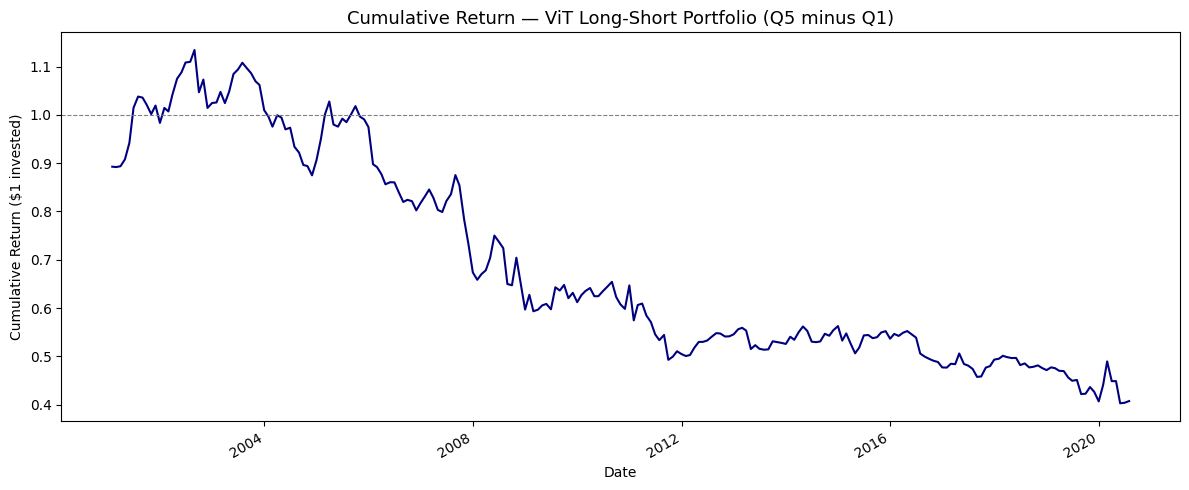

Saved: ls_cumulative_return.png


In [14]:
# Cumulative L/S return
cum_ls = (1+ls).cumprod()
fig, ax = plt.subplots(figsize=(12,5))
cum_ls.plot(ax=ax, color='navy', linewidth=1.5)
ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative Return — ViT Long-Short Portfolio (Q5 minus Q1)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return ($1 invested)')
plt.tight_layout()
plt.savefig('sorted_portfolio/ls_cumulative_return.png', dpi=150)
plt.show()
print('Saved: ls_cumulative_return.png')

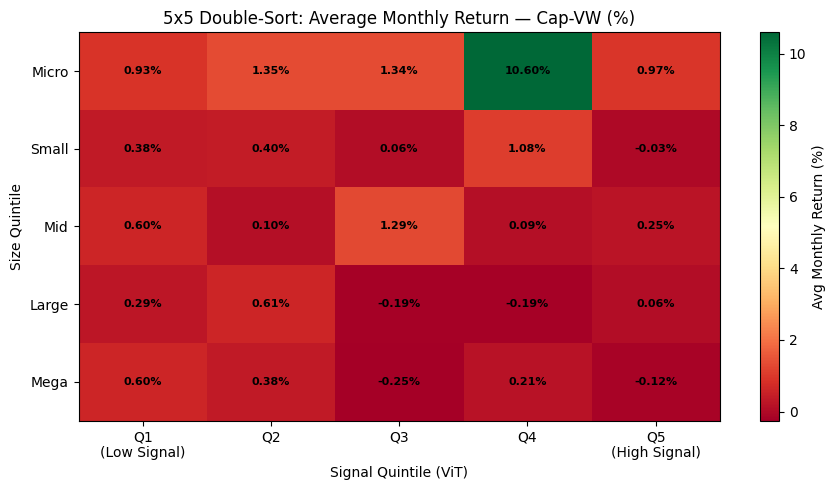

Saved: heatmap_5x5.png


In [15]:
# 5x5 Heatmap
heatmap = df_5x5.groupby(['size_decile_5','signal_decile_5'])['Cap_VW_return'].mean().unstack()*100

fig, ax = plt.subplots(figsize=(9,5))
im = ax.imshow(heatmap.values, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, ax=ax, label='Avg Monthly Return (%)')
ax.set_xticks(range(heatmap.shape[1]))
ax.set_xticklabels(['Q1\n(Low Signal)','Q2','Q3','Q4','Q5\n(High Signal)'][:heatmap.shape[1]])
ax.set_yticks(range(heatmap.shape[0]))
ax.set_yticklabels(['Micro','Small','Mid','Large','Mega'][:heatmap.shape[0]])
ax.set_xlabel('Signal Quintile (ViT)')
ax.set_ylabel('Size Quintile')
ax.set_title('5x5 Double-Sort: Average Monthly Return — Cap-VW (%)')
for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        val = heatmap.values[i,j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.2f}%', ha='center', va='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('sorted_portfolio/heatmap_5x5.png', dpi=150)
plt.show()
print('Saved: heatmap_5x5.png')

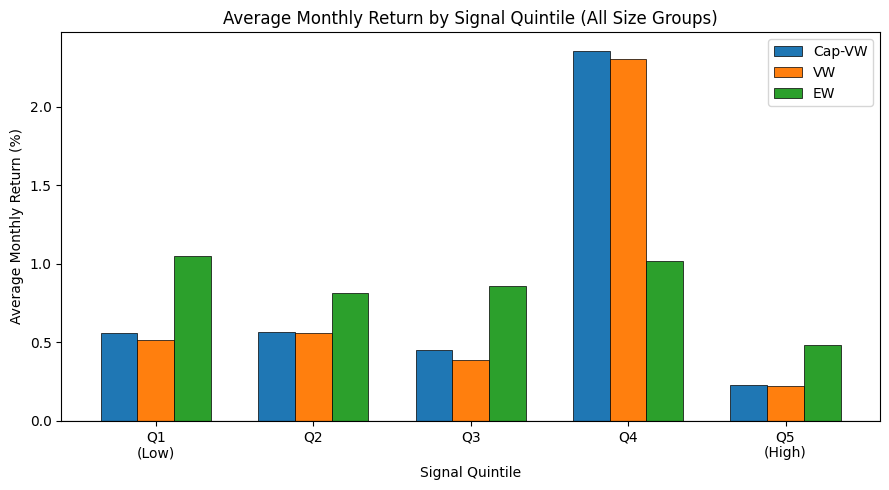

Saved: bar_by_quintile.png


In [16]:
# Bar chart: average return by signal quintile (3 weighting schemes)
avg_plot = df_5x5.groupby('signal_decile_5')[['Cap_VW_return','VW_return','EW_return']].mean()*100
avg_plot.index = ['Q1','Q2','Q3','Q4','Q5']
avg_plot.columns = ['Cap-VW','VW','EW']

fig, ax = plt.subplots(figsize=(9,5))
avg_plot.plot(kind='bar', ax=ax, width=0.7, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Monthly Return by Signal Quintile (All Size Groups)')
ax.set_xlabel('Signal Quintile')
ax.set_ylabel('Average Monthly Return (%)')
ax.set_xticklabels(['Q1\n(Low)','Q2','Q3','Q4','Q5\n(High)'], rotation=0)
ax.legend()
plt.tight_layout()
plt.savefig('sorted_portfolio/bar_by_quintile.png', dpi=150)
plt.show()
print('Saved: bar_by_quintile.png')

---
## STEP 10 — Save results to Google Drive

In [17]:
import shutil

# Save outputs to Drive so they persist after session ends
drive_output = '/content/drive/MyDrive/portfolio_results'
os.makedirs(drive_output, exist_ok=True)

for f in glob('sorted_portfolio/*'):
    shutil.copy(f, drive_output)
    print(f'Saved to Drive: {f}')

print('All results saved to Google Drive!')

Saved to Drive: sorted_portfolio/vit_5by5.csv
Saved to Drive: sorted_portfolio/bar_by_quintile.png
Saved to Drive: sorted_portfolio/ls_cumulative_return.png
Saved to Drive: sorted_portfolio/heatmap_5x5.png
Saved to Drive: sorted_portfolio/vit_3by3.csv
All results saved to Google Drive!
